Project 1:
Author: Chi Hang (Philip) Cheung

For your first project, you are asked to

1. Identify and load a network dataset that has some categorical information available for each node.
2. For each of the nodes in the dataset, calculate **degree centrality** and **eigenvector centrality**.
3. Compare your centrality measures across your categorical groups.
4. For example, using the dataset from a study of romantic relationships among high school students in Columbus, Ohio [http://researchnews.osu.edu/archive/chains.htm], you might want to determine if there are any differences in your calculated centrality measures between the two sexes.  You might use a t-test or another statistical measure to support your findings.

## Dataset: Terrorist Network

Source: 

@inproceedings

{nr,
     title={The Network Data Repository with Interactive Graph Analytics and Visualization},
     author={Ryan A. Rossi and Nesreen K. Ahmed},
     booktitle={AAAI},
     url={https://networkrepository.com},
     year={2015}
}

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

### Load dataset:

In [2]:
edge_df = pd.read_csv('TerroristRel.edges', header=None, names=['source', 'target'])

label_df = pd.read_csv('TerroristRel.node_labels', header=None, names=['ID', 'group'])

#Make a python dict to help translate the personnel into groups:
group_dict = label_df.set_index('ID')['group'].to_dict()


### Loading the data into networkX

In [3]:
#Create nx object:
G = nx.from_pandas_edgelist(edge_df)

#Assignment node attributes:
nx.set_node_attributes(G, group_dict, name='group')

#Assign color to the groups. Terrorist group 1 = RED; Terrorist group 2 = BLUE:
color_map = {1:'red', 2:'blue'}
colors = [color_map.get(G.nodes[n].get('group', 'gray')) for n in G.nodes()]


### Visualizing the Terrorist Network:
#### Group 1 = red; Group 2 = blue

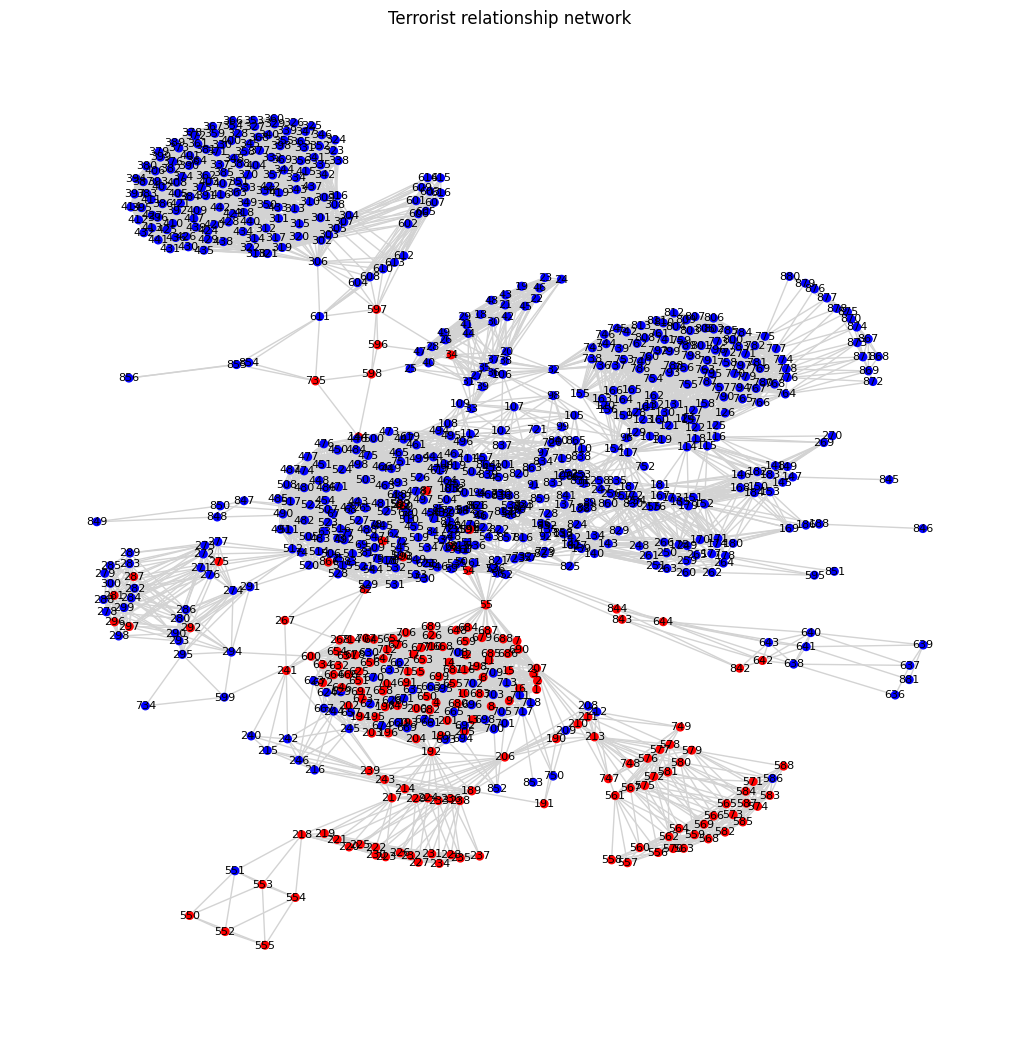

In [4]:
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G)
nx.draw(G, pos=pos, node_color=colors, node_size=30, edge_color='lightgrey', with_labels=True, font_size=8)
plt.title('Terrorist relationship network')
plt.show()

### Calculate the metrics of the network to identify the import figures:

In [5]:
#To find the highest degree centrality node:
deg_cen_node = max(nx.degree_centrality(G).items(), key=lambda x:x[1])

#To find the highest betweeness centrality node:
between_node = max(nx.betweenness_centrality(G).items(), key=lambda x:x[1])

#To find the highest eigenvector node:
eigenvector_node = max(nx.eigenvector_centrality(G).items(), key=lambda x:x[1])

print('-'*80)
print(f"Highest degree centrality node is # {deg_cen_node[0]} and the centrality is {deg_cen_node[1]:.3f}")
print(f"Highest betweeness centrality node is # {between_node[0]} and the centrality is {between_node[1]:.3f}")
print(f"Highest eigenvector centrality node is # {eigenvector_node[0]} and the centrality is {eigenvector_node[1]:.3f}")
print('-'*80)

--------------------------------------------------------------------------------
Highest degree centrality node is # 126 and the centrality is 0.041
Highest betweeness centrality node is # 55 and the centrality is 0.226
Highest eigenvector centrality node is # 301 and the centrality is 0.104
--------------------------------------------------------------------------------


Based on these centrality metrics, we can conclude that although node # 126 has a high degree of connections among the whole network, node # 301 holds the highest influence since it is connected to most of the influencers in the network. A high degree of eigenvector value within a network is often an indication of a master mind who has control of things while avoid attentions and thus a less degree of connections.

Node # 55 serves as the most important 'middle man', which helps connecting different groups of terrorists together. If quick spread of information is needed, node # 55 is the best option for this task.

### Computing statistical metrics:

#### We will merge all the data into a pandas dataframe and calculate the **degree centrality**, **betweeness centrality**, and **eigenvector centrality** for each node.

In [6]:
#Create a data frame:
df = pd.DataFrame(columns=['node', 'group', 'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality'])

#Define the 3 importance metrics:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G)

df['node'] = [n for n in G.nodes()]
df['group'] = df['node'].map(nx.get_node_attributes(G, 'group'))
df['degree_centrality'] = df['node'].map(degree_centrality)
df['betweenness_centrality'] = df['node'].map(betweenness_centrality)
df['eigenvector_centrality'] = df['node'].map(eigenvector_centrality)

#Separate group 1 from group 2:
df_1 = df[df['group'] == 1]
df_2 = df[df['group'] == 2]

#Preview df:
df.head()

,node,group,degree_centrality,betweenness_centrality,eigenvector_centrality
0,1,1,0.018182,0.000000,0.000038
1,2,1,0.018182,0.000000,0.000038
2,3,1,0.018182,0.000000,0.000038
3,4,1,0.035227,0.000253,0.000071
4,5,1,0.036364,0.000489,0.000074


Compare the degree centrality of terrorist in group 1 and group 2

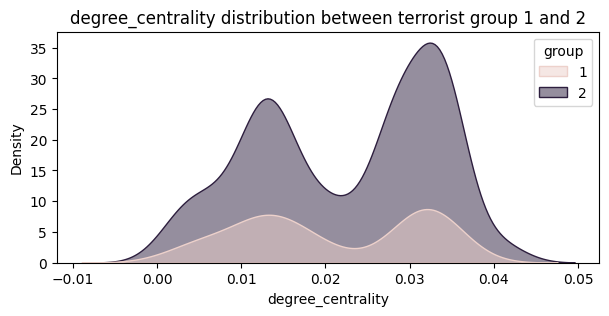

Figure 1: Visualization of degree_centrality


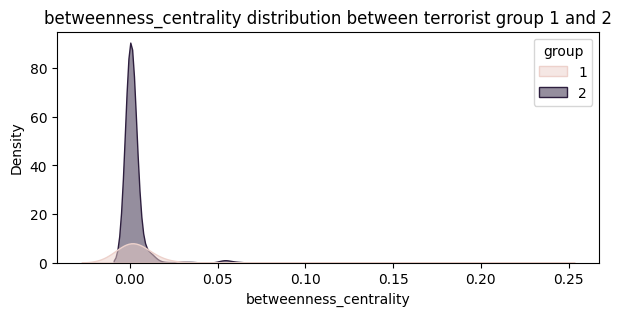

Figure 2: Visualization of betweenness_centrality


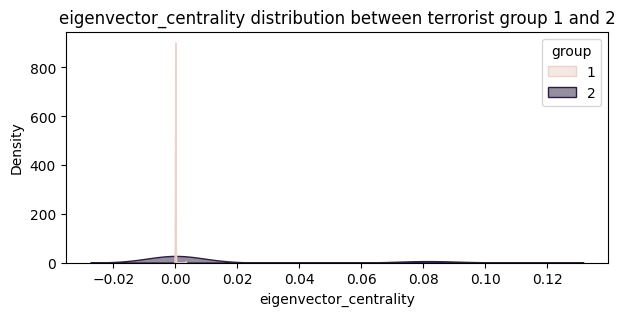

Figure 3: Visualization of eigenvector_centrality


In [7]:
metrics = ['degree_centrality', 'betweenness_centrality', 'eigenvector_centrality']

for num, metric in enumerate(metrics):
    
    plt.figure(figsize=(7,3))
    sns.kdeplot(
        df, 
        x = metric,
        hue = 'group',
        fill = True,
        alpha = 0.5)
    plt.title(f'{metric} distribution between terrorist group 1 and 2')
    
    plt.show()
    print(f'Figure {num+1}: Visualization of {metric}')
   
    

Based on the histogram in figure 1, the degree centrality of group 2 terrorist is much denser and higher than group 1, translating into a higher number of individuals in group 2 being well connected when compared to group 1 members.

On the other hand, figure 2 reveals that most of the operatives in group 2 spikes at around 0 value of between, indicating that those are 'leaf' operative, who do not get to share information to the others. Compared to group 2, group 1 operatives are more spread and able to spread information more quickly. There is one outlier in group 1, which could be operative (node 55) with the highest betweeness centrality.

Visually, Figure 3 shows a stark contrast in influence: Group 1 is almost entirely localized at zero (the sharp spike), indicating these members are isolated from the network's influential core. In contrast, Group 2 shows a much broader distribution with a tail extending toward higher values, housing the network's 'prestigious' leaders. We will have to confirm these results with statistical test.

### Statistical test for Null hypothesis:

#### We will be using Mann-Whitney test at 95% CI here since the distribution of the centralities are skewed or showing multi-model distribution.

#### Parameters for testing:
    1. Degree Centrality
    2. Betweeness Centrality
    3. Eigenvector Centrality

#### Null hypothesis - there is no statistical significance between group 1 and 2 in terms of degree, betweeness, and eigenvector centrality, AKA influence.
#### Alternative hypothesis - there is a statistical significance between the two groups.

In [8]:
for m in metrics:
    mann_whit_stat, mann_whit_p = mannwhitneyu(df_1[m], df_2[m])
    print('-'*80)
    print(f'Mann Whitney stat for **{m}**. Stat: {mann_whit_stat}; and the p-value is: {mann_whit_p:.4f}')
    if mann_whit_p < 0.05:
        print(f'Statistically significant')
    else:
        print(f'Statistically NOT significant')

--------------------------------------------------------------------------------
Mann Whitney stat for **degree_centrality**. Stat: 58505.5; and the p-value is: 0.0554
Statistically NOT significant
--------------------------------------------------------------------------------
Mann Whitney stat for **betweenness_centrality**. Stat: 75187.5; and the p-value is: 0.0004
Statistically significant
--------------------------------------------------------------------------------
Mann Whitney stat for **eigenvector_centrality**. Stat: 67565.0; and the p-value is: 0.2999
Statistically NOT significant


### Conclusion:

As shown above, the statistical test revealed that both groups have influential leaders as we accepted the Null hypothesis of the eigenvector comparsion. On the other hand, the betweeness centrality p-value indicates that group 2 has statistical significance over group 1 in terms of information flow. Few operatives from group 2 are the key figures that help connect few different hubs of terrorist together. This information also shows that this terrorist network might be highly susceptible to targeted attack, resulting in drastic disruption to the entire network. Finally, there is only marginal signifiance in degree centrality between the two groups. We cannot conclude whether one group or the other has more social network than the other.

### Gephi visualization:

In [9]:
#Export the file to Gephi for better visualization:
nx.write_gexf(G, 'Terrorist_network.gexf')

#### Group 1 = red; Group 2 = blue

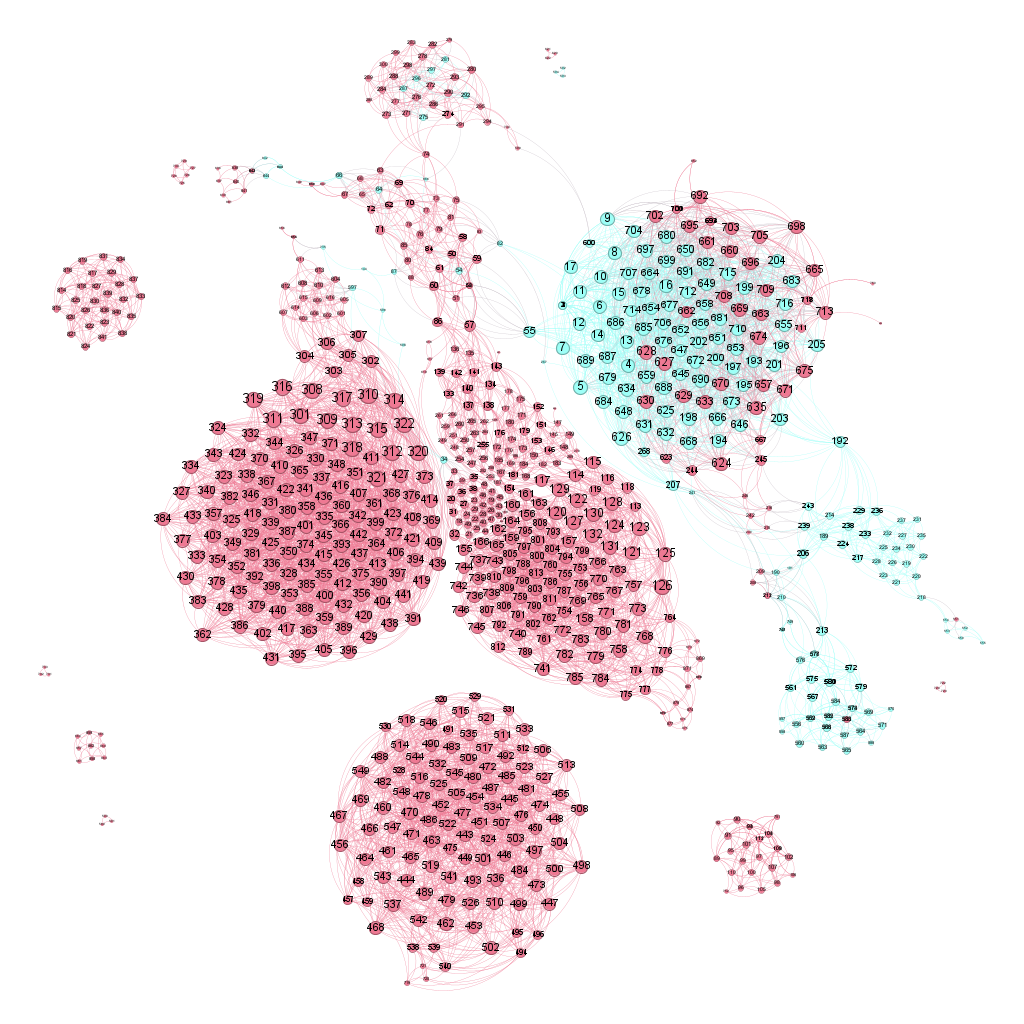

In [10]:
from IPython.display import Image, display

display(Image(filename=('terrorist_net.png')))